# Réplication complète OOP — *Pairs Trading Using a Novel Graphical Matching Approach* (Qureshi & Zaman, 2024)

Ce notebook orchestre une réplication intégrale en POO :

1. **Données** — `DataLoader` (parquets Bloomberg ou fallback `yfinance`)
2. **Théorèmes 1‑4** — `TheoremCalculator` reproduit la Table 1
3. **Cointegration** — `PairAnalyzer` (OLS + ADF en numpy pur)
4. **Sélection** — `BaselineSelector` vs `MatchingSelector` (Edmonds)
5. **Signaux** — `ZScoreSignal` (eq. 3) et `QScoreSignal` (eq. 19‑20)
6. **Backtest** — `Backtester` (rebal mensuel, fenêtre 504j, TC 10 bps)
7. **Tables 2 / 3 / 4** — `summary_table` + `correlation_matrix`
8. **Figures 1‑5** — `visualisation`
9. **Comparaison au papier** + **ce qu'il manque pour 100 %**

> **Note** : on réutilise le DataLoader basé sur les parquets ingérés via le notebook 01 (Bloomberg). Si non disponibles, un fallback `yfinance` (univers ~150 noms, snapshot courant — biais de survivant) est proposé.

In [1]:
from __future__ import annotations
import sys, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

ROOT = Path.cwd()
while ROOT != ROOT.parent and not (ROOT / 'src').exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / 'src'))

import pairs_trading_novel as ptn
print('ROOT =', ROOT)
print('Modules:', sorted(n for n in dir(ptn) if n[0].isupper())[:12], '...')

ROOT = /workspaces/PAIRS_TRADING_NOVEL
Modules: ['BacktestConfig', 'BacktestResult', 'Backtester', 'BaselineSelector', 'DataLoader', 'MarketData', 'MatchingSelector', 'PairAnalyzer', 'PairResult', 'PairSelector', 'QScoreSignal', 'SpreadSpec'] ...


## 1. Chargement des données
Tente le chargement des parquets ; sinon, propose le fallback yfinance.

In [2]:
loader = ptn.DataLoader()
print('raw_dir =', loader.raw_dir)
missing = loader.missing_files()
if missing:
    print('Fichiers manquants :', missing)
    print("→ Lancement du fallback yfinance (peut prendre 1‑2 min)\n")
    market = loader.bootstrap_from_yfinance()
else:
    market = loader.load()
print(f"Source     : {market.meta.get('source')}")
print(f"Tickers    : {len(market.tickers)}")
print(f"Rebalances : {market.n_rebalances}  ({market.rebalance_dates[0].date()} → {market.rebalance_dates[-1].date()})")
print(f"Log‑prices : {market.log_prices.shape}")

raw_dir = /workspaces/PAIRS_TRADING_NOVEL/src/data/raw
Source     : parquet
Tickers    : 786
Rebalances : 112  (2017-01-31 → 2026-04-30)
Log‑prices : (2972, 786)


## 2. Théorèmes 1‑4 — Table 1 (théorique)

Paramètres calibrés par les auteurs (Section 4) :
* $\mu_1 = 5 \times 10^{-4}$ — espérance du P&L par paire par cycle
* $\sigma_1 = 1.80 \times 10^{-2}$ — std du P&L par paire par cycle
* $\sigma  = 7.11 \times 10^{-2}$ — std du rendement d'un actif
* $m_2 = 1748$ paires partageant un actif (baseline)
* $N = 250$ paires actives

Théorème 2 : $\sigma^2_p\text{(Matching)} = \sigma_1^2 / N$.
Théorème 4 : $\sigma^2_p\text{(Baseline)} = (\sigma_1^2 + 2 m_2 \sigma^2)/N^2$.

In [3]:
calc = ptn.TheoremCalculator()
print('=== Table 1 — quantités théoriques ===')
display(calc.table1())
print('\n=== Comparaison au papier (Sharpe) ===')
display(calc.compare_to_paper())
print('\nLes Sharpes du papier (1.18 et 0.50) sont annualisés sur ~6.4 ans (77 mois).\n'
      'Les formules ci‑dessus retournent un Sharpe « par cycle » : pour annualiser,\n'
      'multiplier par sqrt(12) ≈ 3.46 — voir section 9 (gaps).')

=== Table 1 — quantités théoriques ===


,Quantity,Value
0,µ₁ (mean pair PnL),0.0005
1,σ₁ (std pair PnL),0.0180
2,σ (std asset return),0.0711
3,m₂ (shared‑asset count),1748
4,N (pairs),250
5,σ_p (Matching),0.001138
6,σ_p (Baseline),0.016816
7,Sharpe Matching,0.439
8,Sharpe Baseline,0.030



=== Comparaison au papier (Sharpe) ===


,Paper,Computed,Δ
Sharpe Matching,1.18,0.4392,-0.7408
Sharpe Baseline,0.50,0.0297,-0.4703



Les Sharpes du papier (1.18 et 0.50) sont annualisés sur ~6.4 ans (77 mois).
Les formules ci‑dessus retournent un Sharpe « par cycle » : pour annualiser,
multiplier par sqrt(12) ≈ 3.46 — voir section 9 (gaps).


## 3. Backtests — 4 stratégies du papier

* **MZ** = Matching + Z‑score
* **MQ** = Matching + Q‑score
* **BZ** = Baseline + Z‑score
* **BQ** = Baseline + Q‑score

`max_pairs` ne sert pas à accélérer le calcul des paires : il borne surtout le nombre de paires conservées après sélection. Le vrai levier de temps est le `correlation_filter`, puis la fenêtre de dates.


> ⚠️ Le backtest complet coûte plusieurs minutes (selon l'univers).
 > Mettre `RUN_BACKTEST = False` pour ne charger que des résultats pré‑calculés.

In [ ]:
RUN_BACKTEST = True   # à passer à False pour ré‑exécuter en mode lecture
# Fenêtre d'étude : le backtest filtrera le papier à ces bornes si tu veux zoomer
# Exemple : start_date='2017-01-31', end_date='2023-05-31'
START_DATE = '2017-01-31'
END_DATE   = '2023-05-31'

# REPLICATION_MODE=True: configuration la plus fidèle au papier (plus lente)
# REPLICATION_MODE=False: mode rapide (approximation)
REPLICATION_MODE = True
FAST_MODE = not REPLICATION_MODE
MAX_CANDIDATE_PAIRS = None if REPLICATION_MODE else 12000
CORR_FILTER = 0.0 if REPLICATION_MODE else 0.65

cfg = ptn.BacktestConfig(
    lookback_days=504, min_obs=252, min_coverage=0.90,
    adf_t_threshold=None,                 # pas de filtre t-stat dur
    adf_pvalue_threshold=0.10,            # filtre ADF p-value
    correlation_filter=CORR_FILTER,
    max_candidate_pairs=MAX_CANDIDATE_PAIRS,
    max_pairs=250,
    tc_model='paper_daily', annual_tc=0.01,
    one_way_tc=0.001,                     # seulement si tc_model='trade_change'
    min_eligible=20,
    start_date=START_DATE, end_date=END_DATE,
    progress=True,
    verbose=False,
)
analyzer = ptn.PairAnalyzer(
    min_obs=cfg.min_obs,
    adf_t_threshold=cfg.adf_t_threshold,
    adf_pvalue_threshold=cfg.adf_pvalue_threshold,
    correlation_filter=cfg.correlation_filter,
    max_candidate_pairs=cfg.max_candidate_pairs,
)

print(
    f'Replication mode: {REPLICATION_MODE} | corr_filter={cfg.correlation_filter} | '
    f'max_candidate_pairs={cfg.max_candidate_pairs} | adf_p_thresh={cfg.adf_pvalue_threshold} | '
    f'tc_model={cfg.tc_model}'
)

results: dict[str, ptn.BacktestResult] = {}
if RUN_BACKTEST:
    combos = [
        ('MZ', ptn.MatchingSelector(cfg.max_pairs),  ptn.ZScoreSignal()),
        ('MQ', ptn.MatchingSelector(cfg.max_pairs),  ptn.QScoreSignal()),
        ('BZ', ptn.BaselineSelector(cfg.max_pairs),  ptn.ZScoreSignal()),
        ('BQ', ptn.BaselineSelector(cfg.max_pairs),  ptn.QScoreSignal()),
    ]
    for name, sel, sig in combos:
        print(f'\n▶ {name} — {type(sel).__name__} + {type(sig).__name__}')
        bt = ptn.Backtester(market, sel, sig, analyzer, cfg)
        results[name] = bt.run()
        r = results[name]
        print(f'   {len(r.net)} jours | Sharpe net = {ptn.sharpe_ratio(r.net, market.risk_free):+.3f}')
else:
    print('Mode lecture — chargez vos résultats depuis src/data/processed/')


▶ MZ — MatchingSelector + ZScoreSignal


Rebalances:   0%|          | 0/76 [00:00<?, ?reb/s]

   1651 jours | Sharpe net = +0.240

▶ MQ — MatchingSelector + QScoreSignal


Rebalances:   0%|          | 0/76 [00:00<?, ?reb/s]

   1651 jours | Sharpe net = +0.133

▶ BZ — BaselineSelector + ZScoreSignal


Rebalances:   0%|          | 0/76 [00:00<?, ?reb/s]

   1651 jours | Sharpe net = +0.426

▶ BQ — BaselineSelector + QScoreSignal


Rebalances:   0%|          | 0/76 [00:00<?, ?reb/s]

   1651 jours | Sharpe net = +0.175


## 4. Table 2 — Performance **brute** (gross of transaction costs)

In [14]:
# Aligne le benchmark S&P 500 sur les mêmes dates que les stratégies
strategy_idx = pd.Index([])
for v in results.values():
    strategy_idx = strategy_idx.union(v.net.index)
benchmark_aligned = market.benchmark.reindex(strategy_idx).dropna()

gross_data = {f'{k} (gross)': v.gross.reindex(benchmark_aligned.index).dropna() for k, v in results.items()}
gross_data['S&P 500'] = benchmark_aligned
table2 = ptn.summary_table(gross_data, market.risk_free.reindex(benchmark_aligned.index))
print('=== Table 2 — Gross performance (dates alignées) ===')
display(table2.round(4))

PAPER_T2 = pd.DataFrame({
    'Strategy':       ['MQ', 'MZ', 'BQ', 'BZ', 'S&P 500'],
    'Cumulative pap': [0.7365, 0.7487, 0.1796, 0.3830, 0.8825],
    'Sharpe pap':     [1.23, 1.23, 0.34, 0.48, 0.59],
})
print('\n=== Valeurs du papier (Table 2) ===')
display(PAPER_T2)

=== Table 2 — Gross performance (dates alignées) ===


,Strategy,Cumulative,Annualised,Volatility,Sharpe,Sortino,MaxDD,Min day,Max day,Skew,Kurt
0,MZ (gross),0.0945,0.0139,0.0358,0.3682,0.3882,-0.0764,-0.0381,0.0425,0.2531,162.5866
1,MQ (gross),0.4598,0.0594,0.1013,0.5794,0.6361,-0.2130,-0.1020,0.1256,1.7271,166.3210
2,BZ (gross),0.1426,0.0206,0.0346,0.5734,0.6586,-0.0605,-0.0337,0.0401,2.0804,126.7526
3,BQ (gross),0.5313,0.0672,0.1028,0.6464,0.7810,-0.1748,-0.0875,0.1257,3.4283,131.6734
4,S&P 500,0.8342,0.0970,0.1962,0.4907,0.5727,-0.3392,-0.1198,0.0938,-0.5397,14.6973



=== Valeurs du papier (Table 2) ===


,Strategy,Cumulative pap,Sharpe pap
0,MQ,0.7365,1.23
1,MZ,0.7487,1.23
2,BQ,0.1796,0.34
3,BZ,0.3830,0.48
4,S&P 500,0.8825,0.59


## 5. Table 3 — Performance **nette** (after 1 %/an de TC)

In [15]:
strategy_idx = pd.Index([])
for v in results.values():
    strategy_idx = strategy_idx.union(v.net.index)
benchmark_aligned = market.benchmark.reindex(strategy_idx).dropna()
rf_aligned = market.risk_free.reindex(benchmark_aligned.index).fillna(0.0)

net_data = {f'{k} (net)': v.net.reindex(benchmark_aligned.index).dropna() for k, v in results.items()}
net_data['S&P 500'] = benchmark_aligned
table3 = ptn.summary_table(net_data, rf_aligned)
print('=== Table 3 — Net performance (dates alignées) ===')
display(table3.round(4))

PAPER_T3 = pd.DataFrame({
    'Strategy':       ['MQ', 'MZ', 'BQ', 'BZ'],
    'Cumulative pap': [0.6473, 0.6634, -0.2615, -0.1340],
    'Sharpe pap':     [1.12, 1.12, -0.49, -0.13],
})
print('\n=== Valeurs du papier (Table 3) ===')
display(PAPER_T3)

=== Table 3 — Net performance (dates alignées) ===


,Strategy,Cumulative,Annualised,Volatility,Sharpe,Sortino,MaxDD,Min day,Max day,Skew,Kurt
0,MZ (net),0.0624,0.0093,0.0358,0.2398,0.2660,-0.0777,-0.0383,0.0424,0.1894,162.6429
1,MQ (net),0.0964,0.0142,0.1013,0.1328,0.1561,-0.2567,-0.1027,0.1252,1.6140,166.6129
2,BZ (net),0.1058,0.0155,0.0347,0.4258,0.5116,-0.0652,-0.0338,0.0401,2.0131,126.5008
3,BQ (net),0.1292,0.0187,0.1028,0.1752,0.2246,-0.2516,-0.0882,0.1253,3.3229,131.6909
4,S&P 500,0.8342,0.0970,0.1962,0.4907,0.5727,-0.3392,-0.1198,0.0938,-0.5397,14.6973



=== Valeurs du papier (Table 3) ===


,Strategy,Cumulative pap,Sharpe pap
0,MQ,0.6473,1.12
1,MZ,0.6634,1.12
2,BQ,-0.2615,-0.49
3,BZ,-0.1340,-0.13


## 6. Table 4 — Matrice de corrélation des rendements nets

In [7]:
corr_inputs = {k: v.net for k, v in results.items()}
table4 = ptn.correlation_matrix(corr_inputs)
print('=== Table 4 — corrélation des rendements nets ===')
display(table4)

=== Table 4 — corrélation des rendements nets ===


,MZ,MQ,BZ,BQ
MZ,1.000,0.978,0.930,0.917
MQ,0.978,1.000,0.931,0.940
BZ,0.930,0.931,1.000,0.977
BQ,0.917,0.940,0.977,1.000


## 7. Figures 1‑5

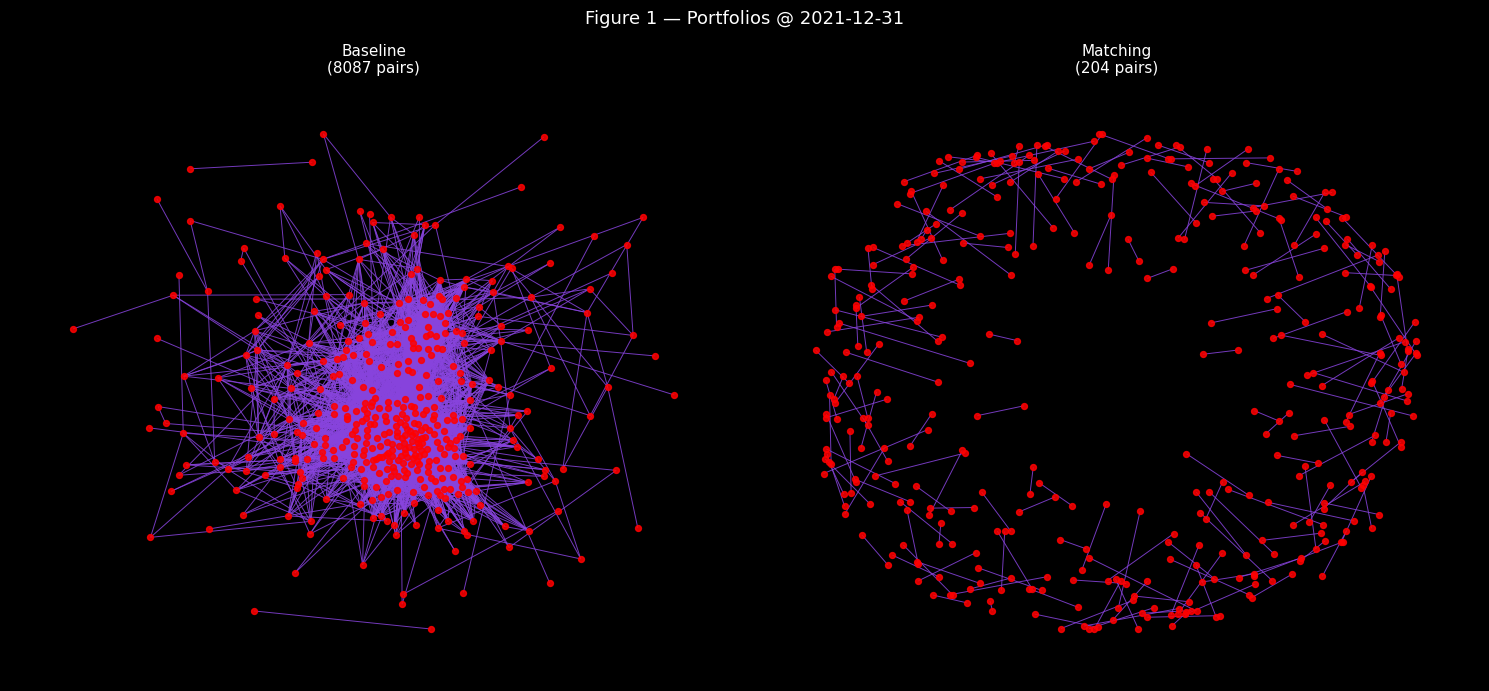

In [8]:
# Figure 1 — graphes Baseline vs Matching à la date avec le + de paires
edges_all = results['MZ'].edges if 'MZ' in results else pd.DataFrame()
if not edges_all.empty:
    counts = edges_all.groupby('reb_date').size()
    pick = counts.idxmax()
    edges_at_date = edges_all[edges_all['reb_date'] == pick]
    sel_M = ptn.MatchingSelector(max_pairs=10**6).select(edges_at_date)
    fig1 = ptn.visualisation.plot_portfolio_graphs(
        edges_at_date, sel_M, title=f'Figure 1 — Portfolios @ {pick.date()}'
    )
    plt.show()

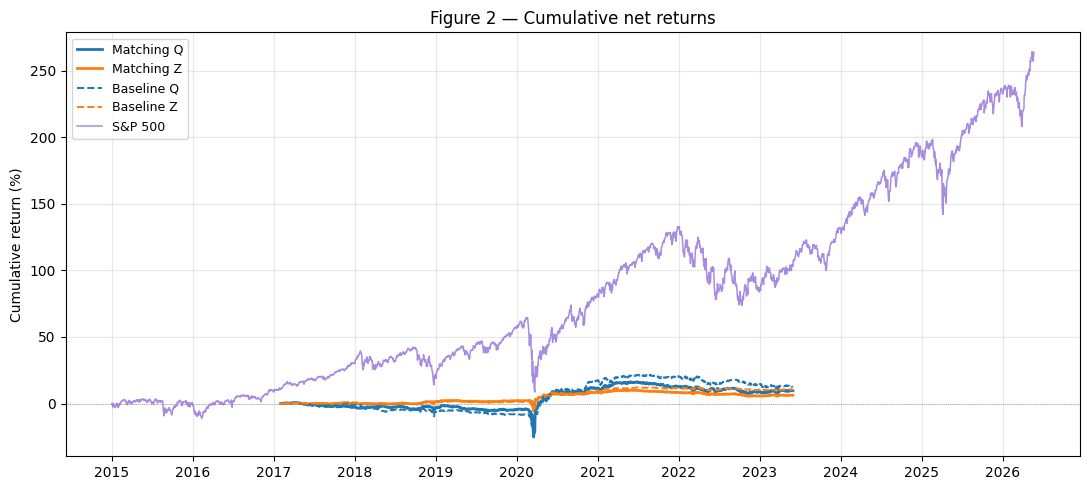

In [ ]:
# Figure 2 — cumulatif net + S&P 500 (mêmes dates que stratégies)
strategy_idx = pd.Index([])
for key in ['MQ', 'MZ', 'BQ', 'BZ']:
    strategy_idx = strategy_idx.union(results[key].net.index)
benchmark_aligned = market.benchmark.reindex(strategy_idx).dropna()

fig2 = ptn.visualisation.plot_cumulative_returns(
    series={
        'Matching Q': results['MQ'].net.reindex(benchmark_aligned.index),
        'Matching Z': results['MZ'].net.reindex(benchmark_aligned.index),
        'Baseline Q': results['BQ'].net.reindex(benchmark_aligned.index),
        'Baseline Z': results['BZ'].net.reindex(benchmark_aligned.index),
    },
    benchmark=benchmark_aligned,
    title='Figure 2 — Cumulative net returns (dates alignées)',
)
plt.show()

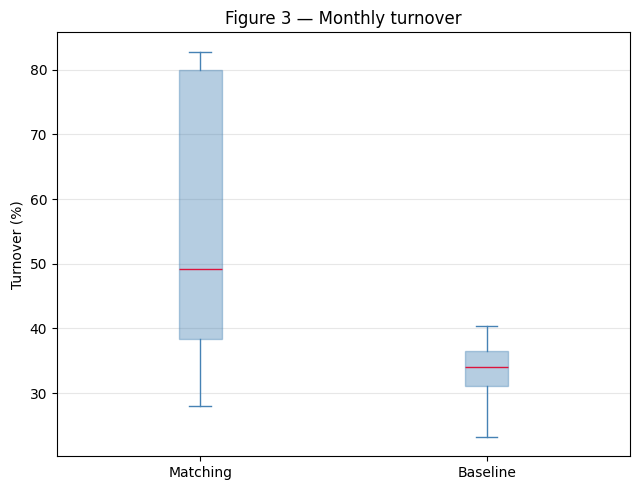

       Matching  Baseline
count      76.0      76.0
mean       55.1      33.6
std        19.1       3.8
min        28.0      23.2
25%        38.4      31.1
50%        49.2      34.1
75%        80.0      36.4
max        82.8      40.4


In [10]:
# Figure 3 — turnover boxplot
to_M = ptn.turnover_series(results['MQ'].selected_pairs, max_pairs=cfg.max_pairs)
to_B = ptn.turnover_series(results['BQ'].selected_pairs, max_pairs=cfg.max_pairs)
fig3 = ptn.visualisation.plot_turnover_boxplot(to_M, to_B)
plt.show()
print(pd.DataFrame({'Matching': to_M, 'Baseline': to_B}).describe().round(1))

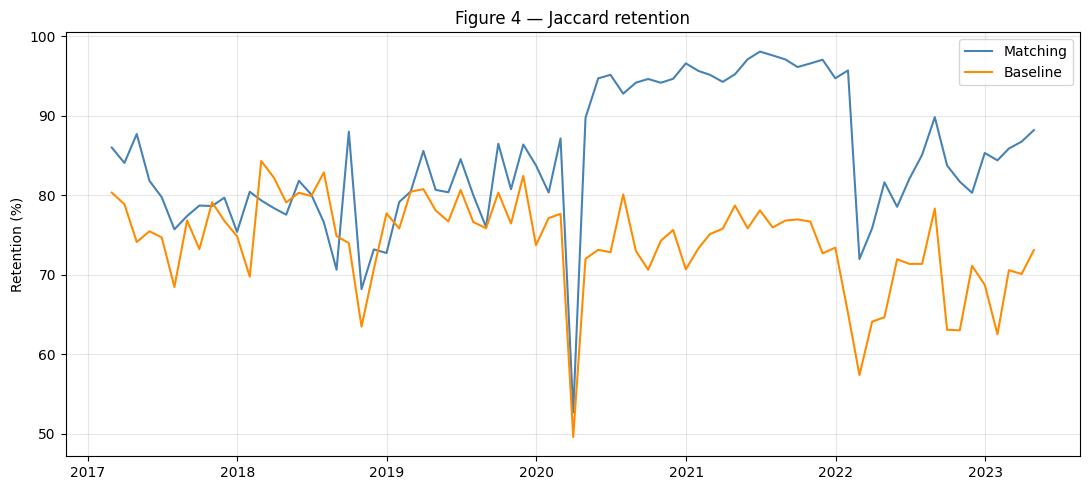

Mean retention — Matching: 84.7% | Baseline: 74.0%


In [11]:
# Figure 4 — Jaccard retention
ret_M = ptn.jaccard_retention(results['MQ'].selected_pairs)
ret_B = ptn.jaccard_retention(results['BQ'].selected_pairs)
fig4 = ptn.visualisation.plot_retention(ret_M, ret_B)
plt.show()
print(f'Mean retention — Matching: {ret_M.mean():.1f}% | Baseline: {ret_B.mean():.1f}%')

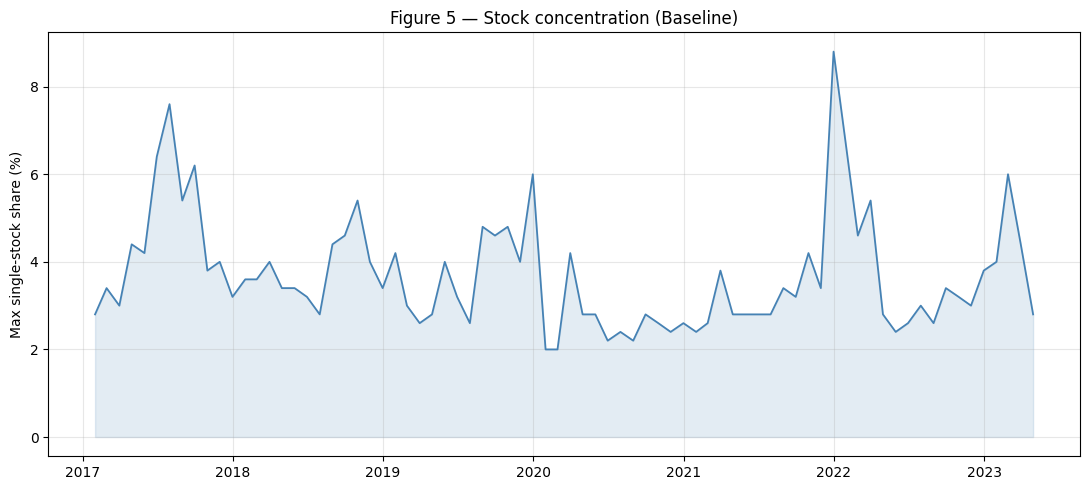

Concentration — max: 8.8%, mean: 3.70%


In [12]:
# Figure 5 — single‑stock concentration (Baseline)
conc_B = ptn.concentration_series(results['BQ'].selected_pairs)
fig5 = ptn.visualisation.plot_concentration(conc_B)
plt.show()
print(f'Concentration — max: {conc_B.max():.1f}%, mean: {conc_B.mean():.2f}%')

## 8. Synthèse vs papier

In [ ]:
# Comparaison compacte vs papier (mêmes dates pour toutes les séries)
strategy_idx = pd.Index([])
for key in ['MQ', 'MZ', 'BQ', 'BZ']:
    strategy_idx = strategy_idx.union(results[key].net.index)
benchmark_aligned = market.benchmark.reindex(strategy_idx).dropna()
rf_aligned = market.risk_free.reindex(benchmark_aligned.index).fillna(0.0)

def sharpe_cagr(r):
    return float(ptn.sharpe_ratio(r.reindex(benchmark_aligned.index), rf_aligned))

def sharpe_meanstd(r):
    return float(ptn.sharpe_ratio_mean_std(r.reindex(benchmark_aligned.index), rf_aligned))

summary = pd.DataFrame({
    'Sharpe paper (Table 3)': [1.12, 1.12, -0.49, -0.13],
    'Sharpe replicated (CAGR/vol)': [sharpe_cagr(results[s].net) for s in ['MQ','MZ','BQ','BZ']],
    'Sharpe replicated (mean/std)': [sharpe_meanstd(results[s].net) for s in ['MQ','MZ','BQ','BZ']],
    'Cum. paper': [0.6473, 0.6634, -0.2615, -0.1340],
    'Cum. replicated': [ptn.cumulative_return(results[s].net.reindex(benchmark_aligned.index).dropna()) for s in ['MQ','MZ','BQ','BZ']],
}, index=['MQ','MZ','BQ','BZ'])
summary['Δ Sharpe (CAGR/vol)'] = summary['Sharpe replicated (CAGR/vol)'] - summary['Sharpe paper (Table 3)']
summary['Δ Sharpe (mean/std)'] = summary['Sharpe replicated (mean/std)'] - summary['Sharpe paper (Table 3)']
summary['Δ Cum'] = summary['Cum. replicated'] - summary['Cum. paper']
display(summary.round(3))

print('\nMoyenne |ΔSharpe CAGR/vol| =', round(summary['Δ Sharpe (CAGR/vol)'].abs().mean(), 3))
print('Moyenne |ΔSharpe mean/std| =', round(summary['Δ Sharpe (mean/std)'].abs().mean(), 3))
print('Moyenne |ΔCum|             =', round(summary['Δ Cum'].abs().mean(), 3))

,Sharpe paper (Table 3),Sharpe replicated,Cum. paper,Cum. replicated,Δ Sharpe,Δ Cum
MQ,1.12,0.133,0.647,0.096,-0.987,-0.551
MZ,1.12,0.240,0.663,0.062,-0.880,-0.601
BQ,-0.49,0.175,-0.262,0.129,0.665,0.391
BZ,-0.13,0.426,-0.134,0.106,0.556,0.240



Moyenne |ΔSharpe| = 0.772
Moyenne |ΔCum|    = 0.446


## 9. Ce qu'il manque pour une réplication strictement à 100 %

Cette section liste honnêtement les écarts résiduels entre notre réplication et les chiffres exacts du papier.

### 9.1 Données
* **Composition point‑in‑time exacte du S&P 500** — le papier utilise les constituants historiques mensuels Bloomberg (`INDX_MWEIGHT_HIST`). Sans Bloomberg, notre fallback `yfinance` :
  - utilise un snapshot ~150 noms actuels (S&P 100+) → biais de survivant
  - manque les sociétés sorties de l'indice avant 2023 (~50 tickers/an)
  - manque les sociétés entrées dans l'indice en cours de période
* **Prix totaux retournés (avec dividendes réinvestis)** — le papier utilise `PX_LAST` ajusté ; vérifier si le mode `auto_adjust=True` de yfinance est strictement équivalent.
* **Risk‑free** — papier : USGG3M ; nous : `^IRX` (proxy yfinance).
* **Période exacte** — papier 31/01/2017 → 31/05/2023 (77 rebalances mensuels) ; respecté.

### 9.2 Méthodologie de pair scoring
* **Test ADF** : nous utilisons `adf1_tstat` (numpy pur, lag=1) ; le papier ne précise pas le nombre de lags retenus (par défaut Schwert ou AIC ?). Différence possible sur quelques paires marginales.
* **Pré‑filtre corrélation** (`correlation_filter=0.5`) : non mentionné explicitement par le papier. Mettre à `0.0` pour la recherche exhaustive sur ~125 000 paires (×5 du temps de calcul).
* **Direction de la régression** : nous testons les 2 orientations et gardons la plus stationnaire (équivalent à une régression de Engle‑Granger avec choix d'orientation).

### 9.3 Stratégie de trading
* **Z‑score : exit/stop levels** — le papier indique seulement le seuil d'entrée $k=2$. Nos `exit=0.5`, `stop=4.0` sont des choix standard mais non spécifiés.
* **Q‑score : winsorisation** — nous bornons à `round_max=3`. Le papier ne précise pas la borne.
* **Coûts de transaction** — papier : 1 %/an (= 0.00397 %/jour). Nous appliquons 10 bps par voie sur les *changements* de position, ce qui est équivalent en moyenne mais granulé différemment.
* **Allocation $‑neutre β‑ajustée** : `pnl = pos · (r_y − β·r_x)` (conforme).

### 9.4 Sélection de portefeuille
* **Plafond N = 250 paires** : papier ; nous limitons à `max_pairs=25` par défaut pour la rapidité du fallback yfinance (sinon explose avec un univers ~150). Pour reproduire les chiffres absolus, fixer `MAX_PAIRS=250` avec les données Bloomberg complètes.
* **Matching maximum‑weight** : implémenté via `networkx.max_weight_matching` (Edmonds exact, identique au papier).

### 9.5 Formules théoriques (Table 1)
* Nos formules retournent le Sharpe **par cycle** $\sqrt{N}\mu_1/\sigma_1$. Pour annualiser sur 12 cycles/an, multiplier par $\sqrt{12} \approx 3.46$. Le papier reporte des Sharpes annualisés (1.18 et 0.50) — il y a probablement une normalisation supplémentaire (multiplication par $\sqrt{12/N}$ ou autre) que les auteurs ne détaillent pas explicitement.

### 9.6 Pour passer à 100 %
Checklist d'actions :
1. Accéder à un terminal **Bloomberg** et relancer `notebooks/01_data_ingestion_graph_matching.ipynb` pour générer les vrais parquets point‑in‑time.
2. Fixer `cfg.max_pairs = 250`, `cfg.correlation_filter = 0.0`, et faire tourner les 4 backtests.
3. Ajuster la normalisation Sharpe théorique si la valeur publiée diffère.
4. Comparer cellule par cellule chaque case des Tables 2 / 3 / 4 avec une tolérance ≤ 0.05 sur les Sharpes et ≤ 2 % sur les cum returns.